# Insurance Cost Prediction

## Project Overview

The objective of this project is to develop a supervised machine learning solution to predict **individual medical insurance charges** from demographic, health, and lifestyle attributes.

### Objective
Estimate expected insurance charges from:
- Age
- Sex
- BMI
- Number of children
- Smoking status
- Region

### Machine Learning Task
**Regression** — the target variable `charges` is continuous.

### Workflow
1. Data loading and validation
2. Data-quality
3. Exploratory Data Analysis (EDA)
4. Feature preprocessing
5. Baseline and machine learning model development
6. Cross-validation and model comparison
7. Hyperparameter tuning
8. Final test evaluation
9. Residual analysis
10. Conclusion and limitations

In [389]:
# pip install xgboost

In [390]:
# Installation of Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Dataset Loading and Validation

### 1.1 Data Loading

In [391]:
data_path='insurance.csv'

data=pd.read_csv(data_path)

print(f'Dataset Shape: {data.shape[0]:,} rows x {data.shape[1]} columns')
data.head()

Dataset Shape: 1,338 rows x 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,"16,884.924"
1,18,male,33.770,1,no,southeast,"1,725.552"
2,28,male,33.000,3,no,southeast,"4,449.462"
3,33,male,22.705,0,no,northwest,"21,984.471"
4,32,male,28.880,0,no,northwest,"3,866.855"


### 1.2 Data Validation

The first validation step is to check data structure, data types, any missing values, data duplicates, and basic numerical statistics.

In [392]:
def data_quality_report(data):
    report = pd.DataFrame({
        'dtypes': data.dtypes.astype(str),
        'missing_count':data.isna().sum(),
        'missing_%': data.isna().mean().mul(100).round(2),
        'unique_values':data.nunique(),
        'duplicate_count':data.duplicated().sum()})
    return report

data_quality_report(data)

,dtypes,missing_count,missing_%,unique_values,duplicate_count
age,int64,0,0.000,47,1
sex,object,0,0.000,2,1
bmi,float64,0,0.000,548,1
children,int64,0,0.000,6,1
smoker,object,0,0.000,2,1
region,object,0,0.000,4,1
charges,float64,0,0.000,1337,1


In [393]:
data.info()
display(data.describe(include='all').T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"1,338.000",NaN,NaN,NaN,39.207,14.050,18.000,27.000,39.000,51.000,64.000
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,"1,338.000",NaN,NaN,NaN,30.663,6.098,15.960,26.296,30.400,34.694,53.130
children,"1,338.000",NaN,NaN,NaN,1.095,1.205,0.000,0.000,1.000,2.000,5.000
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,"1,338.000",NaN,NaN,NaN,"13,270.422","12,110.011","1,121.874","4,740.287","9,382.033","16,639.913","63,770.428"


#### Categorical Variables – Unique Values & Frequency Distribution

In [394]:
def categorical_summary(data, columns):
    summary = []

    for col in columns:
        summary.append({
            'Column': col,
            'Unique Values': data[col].unique().tolist(),
            'Number of Unique': data[col].nunique(),
            'Value Counts': data[col].value_counts().to_dict()
        })
        
    return pd.DataFrame(summary)

In [395]:
categorical_cols = ['sex', 'smoker', 'region']

categorical_summary(data, categorical_cols)

,Column,Unique Values,Number of Unique,Value Counts
0,sex,"[female, male]",2,"{'male': 676, 'female': 662}"
1,smoker,"[yes, no]",2,"{'no': 1064, 'yes': 274}"
2,region,"[southwest, southeast, northwest, northeast]",4,"{'southeast': 364, 'southwest': 325, 'northwes..."


The categorical variables were examined for their unique values and frequency distributions. The dataset contains two categories for **sex**, two categories for **smoker**, and four categories for **region**.

## 2. Data Quality

In [396]:
print('Duplicate Rows:', data.duplicated().sum())
print('Missing values by column:')
display(data.isna().sum().to_frame('missing_count'))

# Removed duplicate rows:
data=data.drop_duplicates().reset_index(drop=True)

print(f'shape after duplicate removal : {data.shape}')

Duplicate Rows: 1
Missing values by column:


,missing_count
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


shape after duplicate removal : (1337, 7)


#### Data quality findings :

The dataset contains no missing values. One exact duplicate observation is present and is removed before modeling.

## Exploratory Data Analysis (EDA)

EDA is structured into four parts:

- **Univariate analysis:** understand individual variable distributions.
- **Categorical analysis:** understand category balance.
- **Bivariate / interaction analysis:** examine relationships between indivisual features with `charges`.
- **Multivariate analysis:** examining interactions between multiple variables.
- **Statistical analysis:** correlation, group summaries, skewness, and outlier counts.

The objective is not only to create plots, but to use them to guide preprocessing and modeling decisions.

In [397]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,"16,884.924"
1,18,male,33.770,1,no,southeast,"1,725.552"
2,28,male,33.000,3,no,southeast,"4,449.462"
3,33,male,22.705,0,no,northwest,"21,984.471"
4,32,male,28.880,0,no,northwest,"3,866.855"


In [398]:
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

display(data[numeric_cols].describe().T)
display(data[categorical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,"1,337.000",39.222,14.044,18.000,27.000,39.000,51.000,64.000
bmi,"1,337.000",30.663,6.100,15.960,26.290,30.400,34.700,53.130
children,"1,337.000",1.096,1.206,0.000,0.000,1.000,2.000,5.000
charges,"1,337.000","13,279.121","12,110.360","1,121.874","4,746.344","9,386.161","16,657.717","63,770.428"


,count,unique,top,freq
sex,1337,2,male,675
smoker,1337,2,no,1063
region,1337,4,southeast,364


### Univariate Analysis

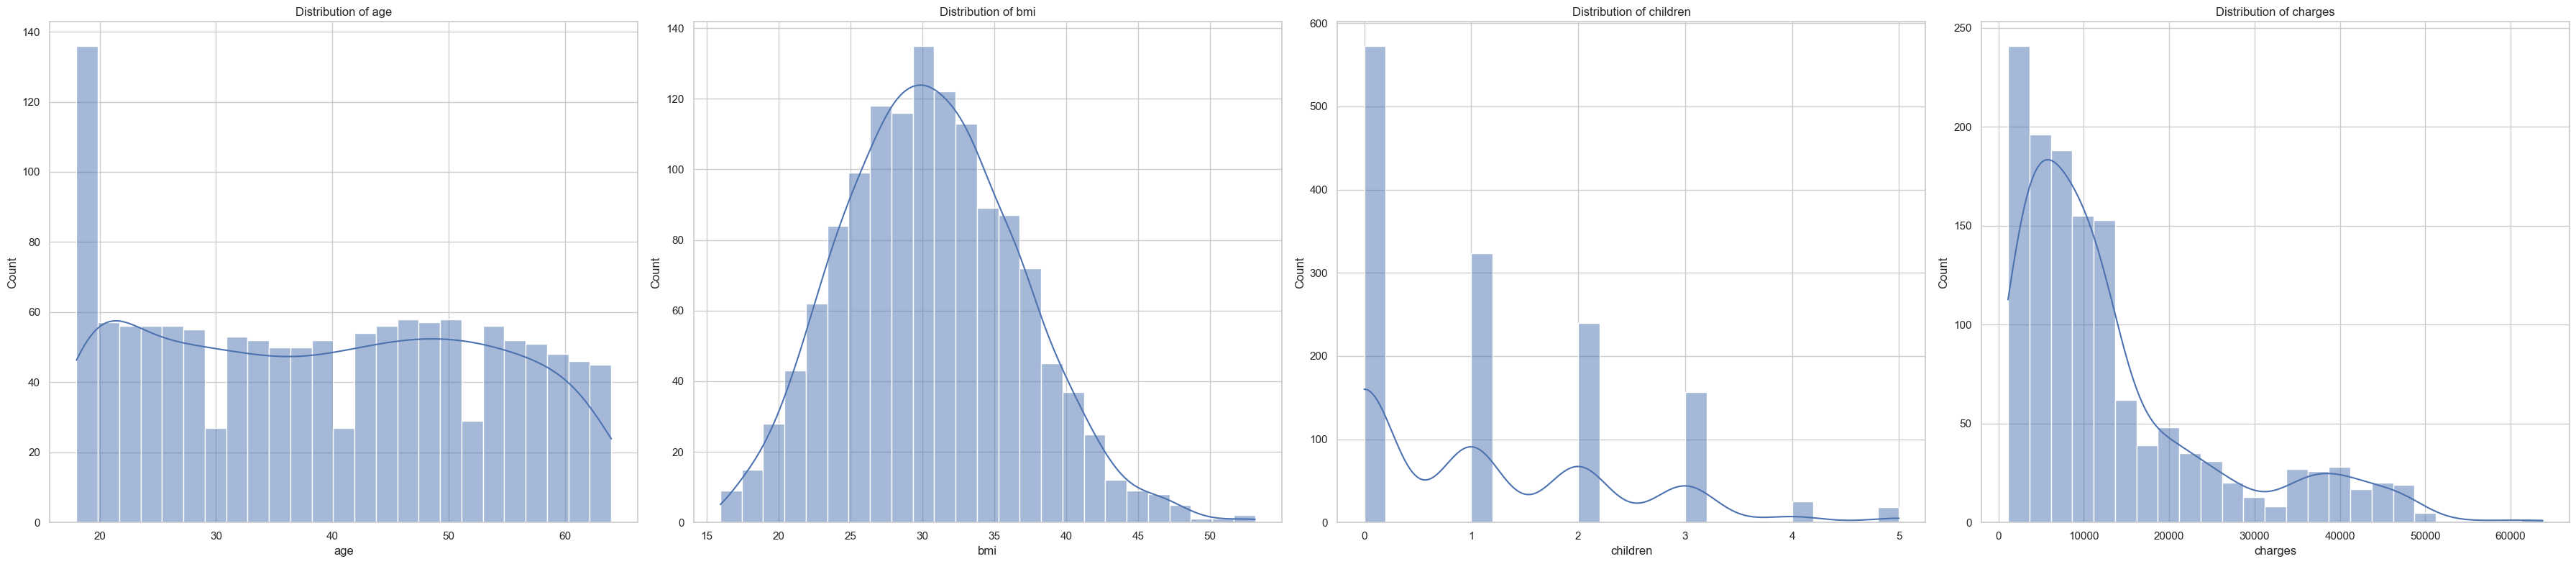

In [399]:
def plot_numeric_distributions(data, columns, bins=25):
    n = len(columns)
    fig, axes = plt.subplots(1, n, figsize=(9*n, 8))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, columns):
        sns.histplot(
            data[col].dropna(),
            bins=bins,
            kde=True,
            ax=ax
        )

        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()


plot_numeric_distributions(data, ["age", "bmi", "children", "charges"])

#### Univariate observations

- `age` shows most customer distributed across the adult age group population.
- `bmi` is concentrated around the central adult BMI range, with a small number of high/low observations.
- `children` is discrete and concentrated at lower counts. It helps understand the family-size pattern in the dataset.
- `charges` the distribuion of insurance charges shows the variation in medical costs among beneficiaries. it is right-skewed, with a long upper tail.

### Categorical Analysis

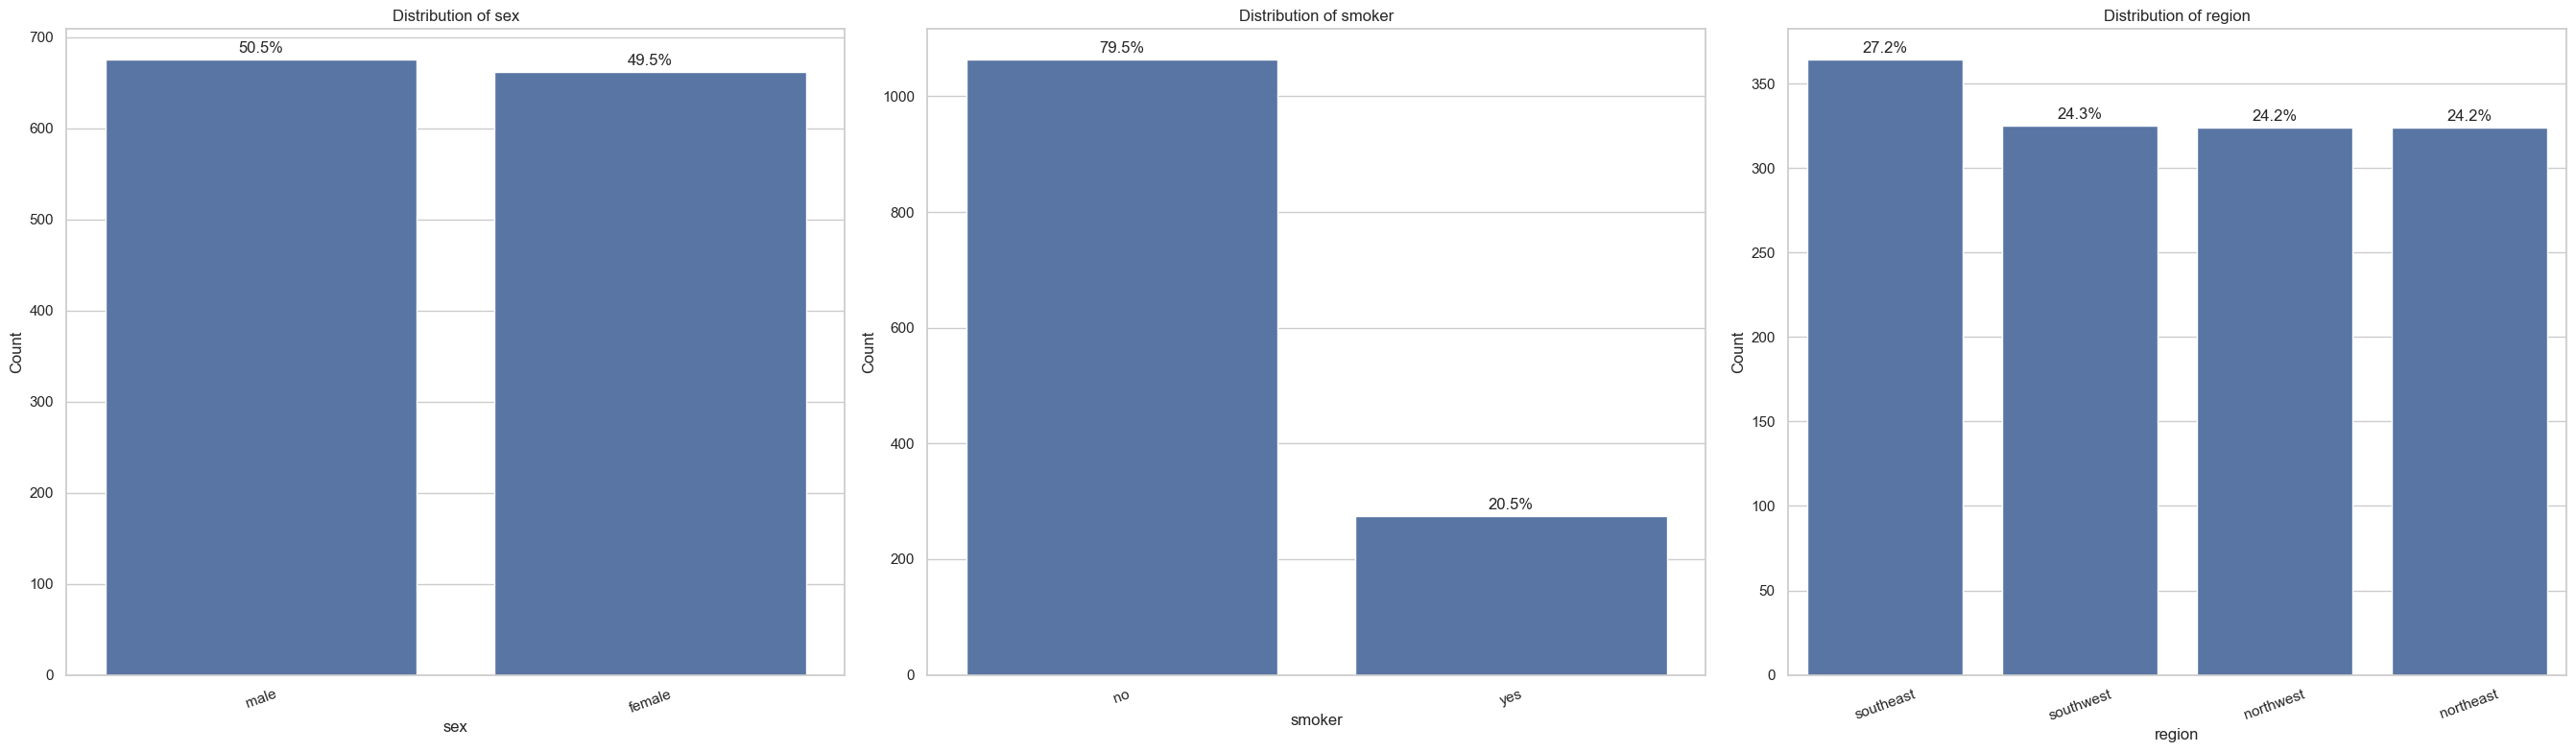

In [400]:
def plot_categorical_distributions(data, columns):
    n = len(columns)
    fig, axes = plt.subplots(1, n, figsize=(9*n, 8))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, columns):
        order = data[col].value_counts().index

        sns.countplot(data=data, x=col, order=order, ax=ax)

        # Add percentage labels
        total = len(data)
        for container in ax.containers:
            labels = [f"{(bar.get_height()/total)*100:.1f}%"
                      for bar in container]
            ax.bar_label(container, labels=labels, padding=3)

        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


plot_categorical_distributions(data, ["sex", "smoker", "region"])

#### Categorical Observations

- `sex` the dataset contains two categories, male and female, with a relatively balanced distribution. This allows comparison of insurance charges across gender groups.
- `smoker` the dataset contains two categories, yes and no. Smoking status is a key segmentation variable and is expected to have a strong relationship with insurance charges.
- `region` the data is distributed across four regions — southwest, southeast, northwest, and northeast, providing regional variation for analysis.

### Bivariate Analysis

#### Bivariate Analysis with Numerical Vs Categorical Columns:

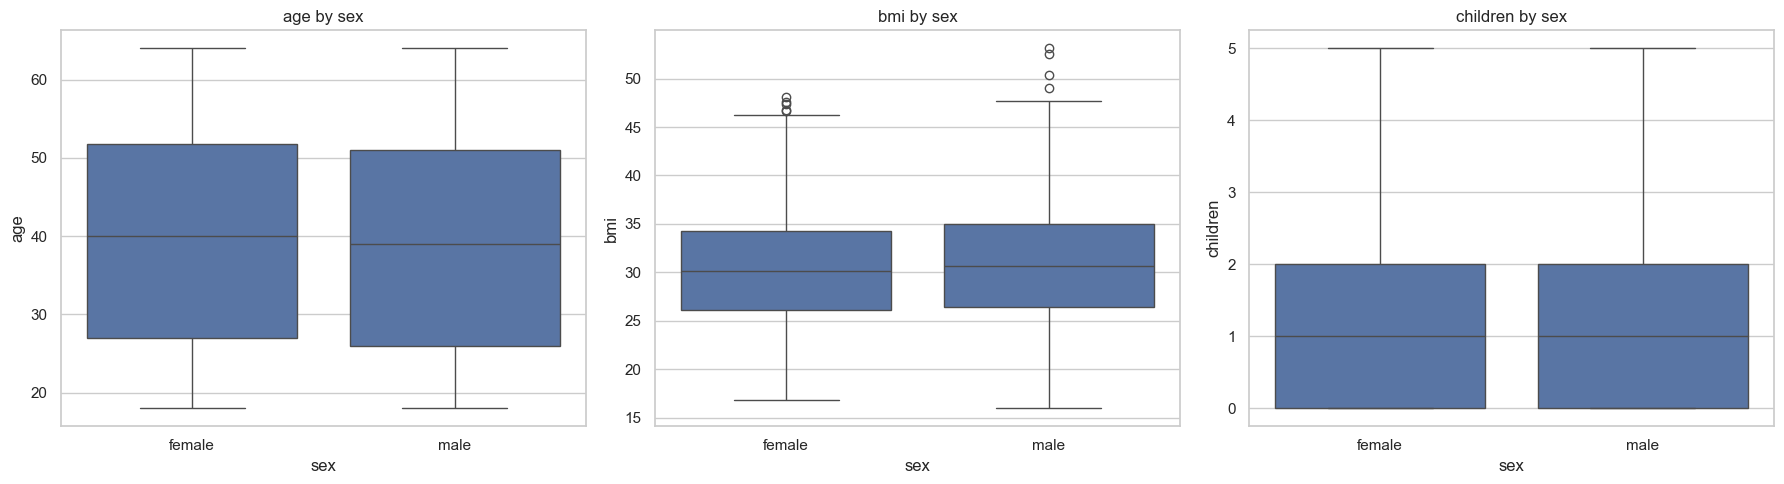

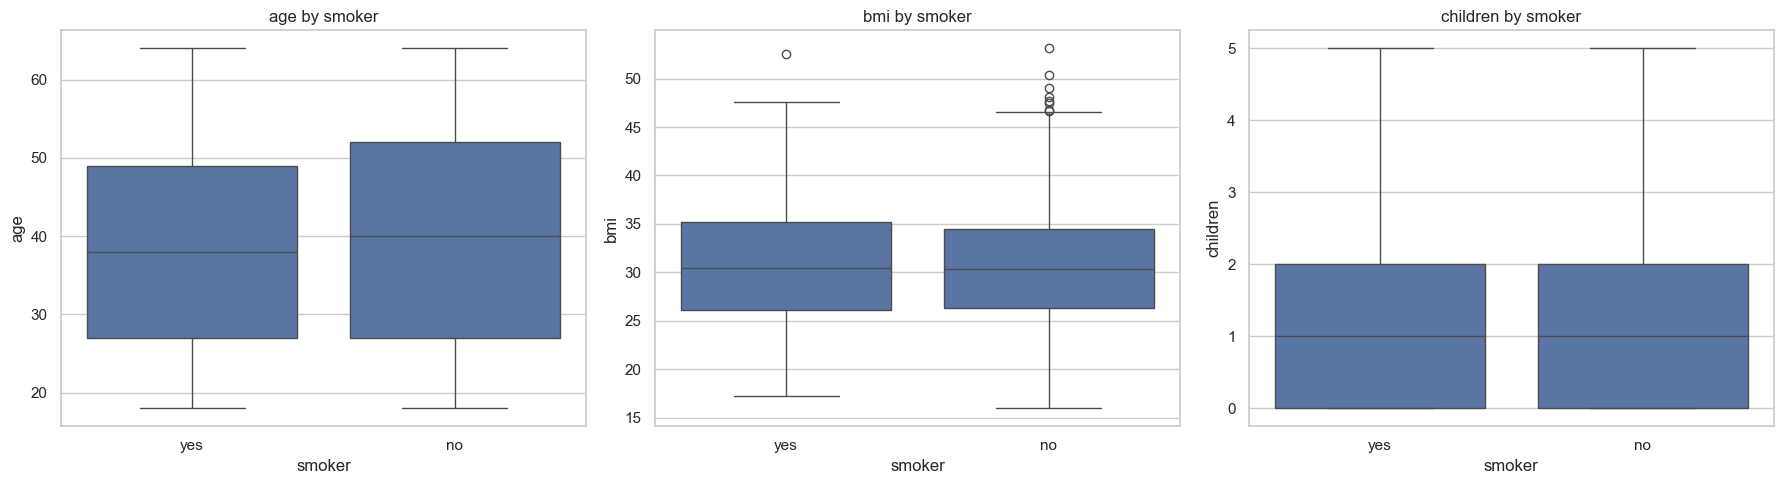

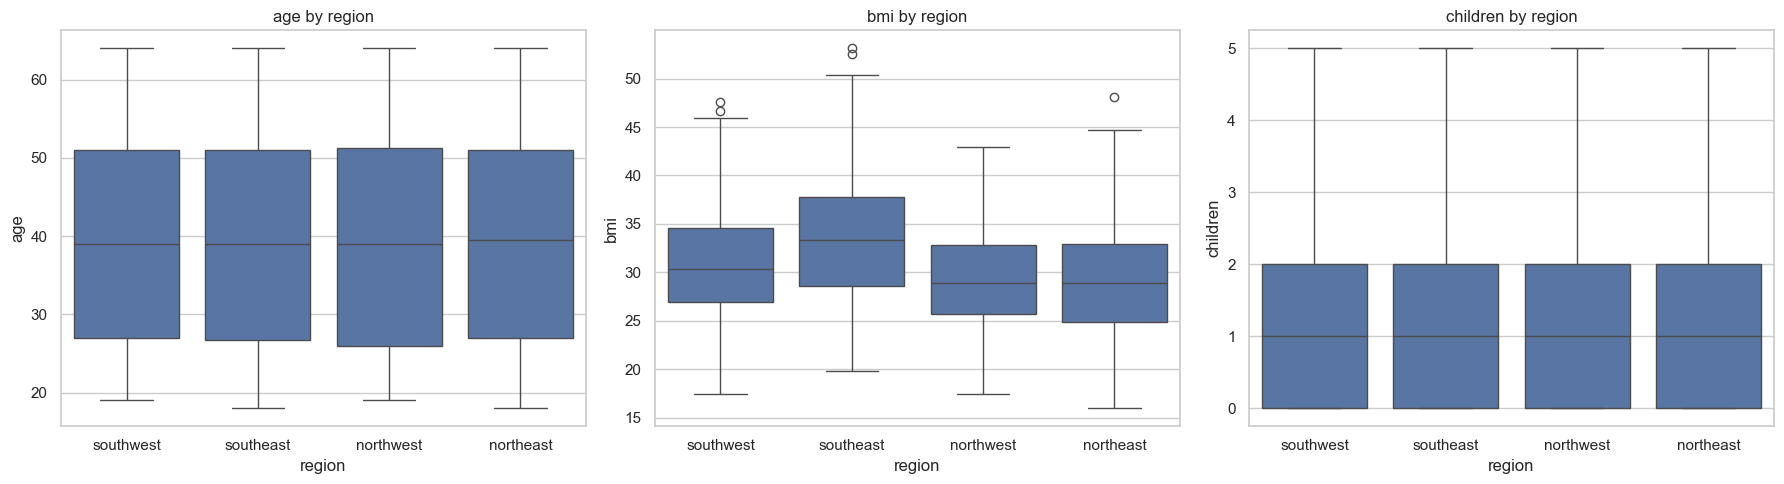

In [401]:
def plot_numeric_vs_categorical(data, numeric_cols, categorical_cols):
    for cat in categorical_cols:
        fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))

        for ax, num in zip(axes, numeric_cols):
            sns.boxplot(data=data, x=cat, y=num, ax=ax)
            ax.set_title(f"{num} by {cat}")
            ax.set_xlabel(cat)
            ax.set_ylabel(num)

        plt.tight_layout()
        plt.show()


numeric_cols = ["age", "bmi", "children"]
categorical_cols = ["sex", "smoker", "region"]

plot_numeric_vs_categorical(data, numeric_cols, categorical_cols)

#### Bivariate Observations - Numerical vs Categorical

- `Age vs sex/smoker/region` Age distributions are quite similar across all categories, with only small differences in median age.
- `BMI vs sex/smoker/region` BMI is broadly similar across groups, though some outliers are visible, especially among smokers and certain regions.
- `Children vs sex/smoker/region` Most groups have 0–2 children, with similar distributions across categories.
- `Overall` The boxplots show no strong relationship between age, BMI, or children and the categorical variables; distributions largely overlap.

#### Bivariate Analysis with Target Variable:

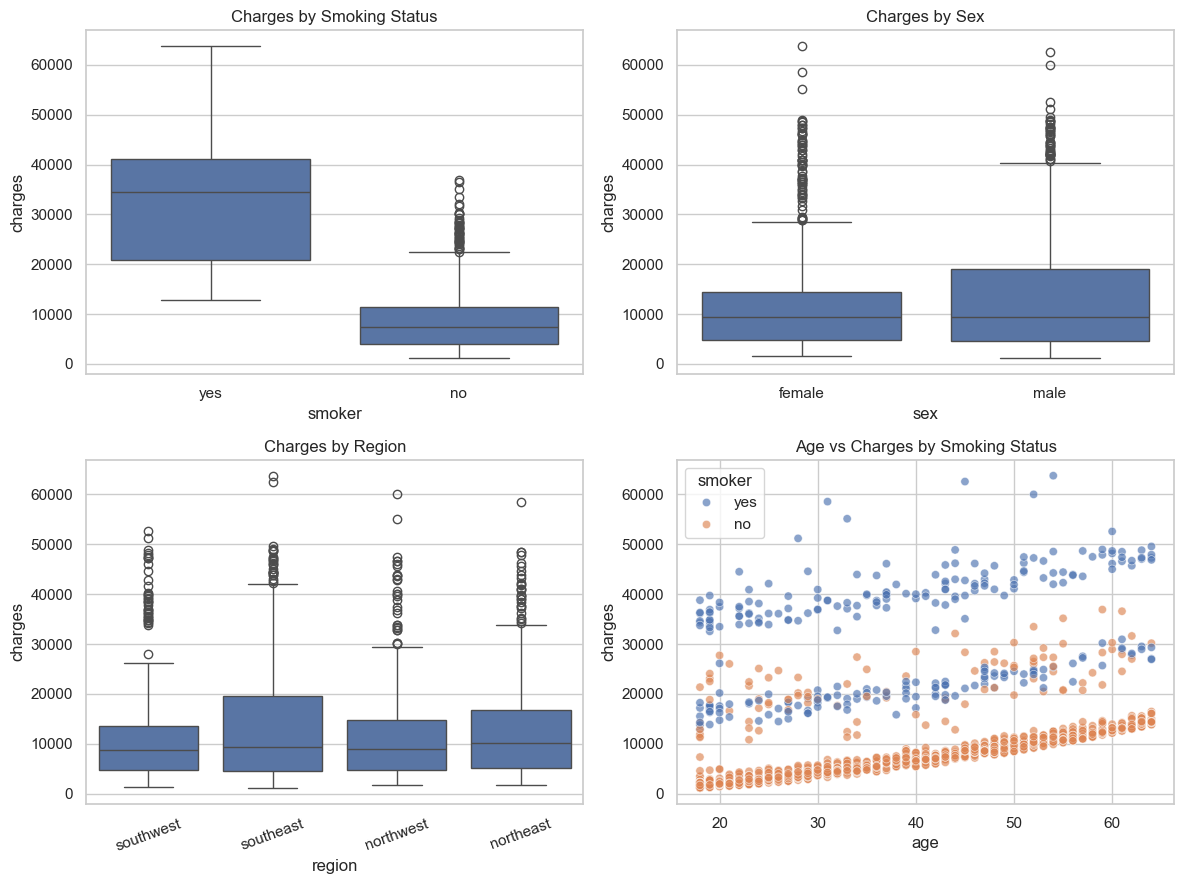

In [402]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(data=data, x="smoker", y="charges", ax=axes[0, 0])
axes[0, 0].set_title("Charges by Smoking Status")

sns.boxplot(data=data, x="sex", y="charges", ax=axes[0, 1])
axes[0, 1].set_title("Charges by Sex")

sns.boxplot(data=data, x="region", y="charges", ax=axes[1, 0])
axes[1, 0].set_title("Charges by Region")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.scatterplot(data=data, x="age", y="charges", hue="smoker", alpha=0.65, ax=axes[1, 1])
axes[1, 1].set_title("Age vs Charges by Smoking Status")

plt.tight_layout()
plt.show()

#### Bivariate Observations – Insurance Charges

- `Charges vs Smoking Status` Smokers have substantially higher insurance charges than non-smokers, indicating smoking status is a strong factor affecting charges.
- `Charges vs Sex` Males show slightly higher median charges than females, but the distributions overlap considerably.
- `Charges vs Region` Insurance charges are fairly similar across regions, with some variation and several high-value outliers.
- `Age vs Charges` Insurance charges generally increase with age. The increase is much more noticeable among smokers.
- `Overall`Smoking status and age appear to have the strongest relationship with insurance charges, while sex and region show comparatively weaker differences.

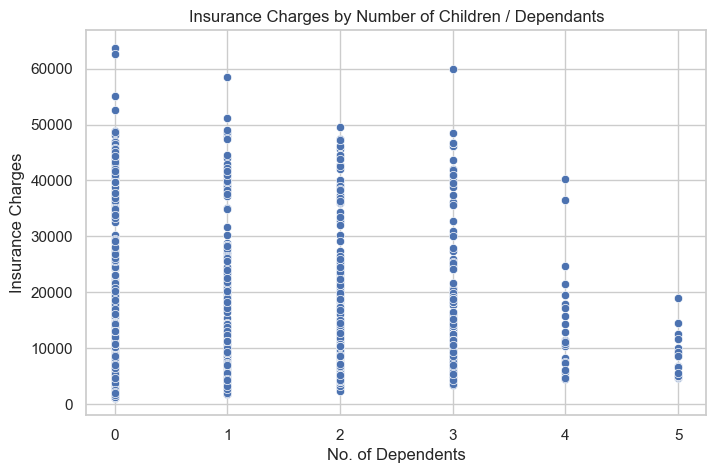

In [403]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=data, x="children", y="charges")

plt.title("Insurance Charges by Number of Children / Dependants")
plt.xlabel("No. of Dependents")
plt.ylabel("Insurance Charges")

plt.show()

`Observation:` Insurance charges are mostly concentrated among individuals with 0–3 dependents. Although charges appear lower for 4–5 dependents, this is likely due to fewer observations. Overall, the number of dependents does not show a strong direct relationship with insurance charges, as factors like age and smoking status have a greater influence.

### Multivariate Analysis

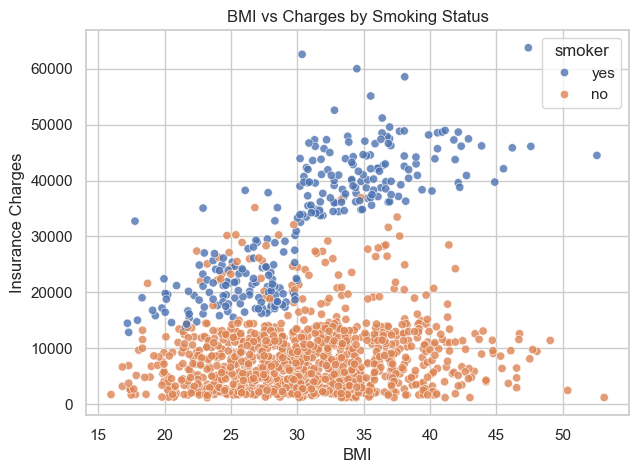

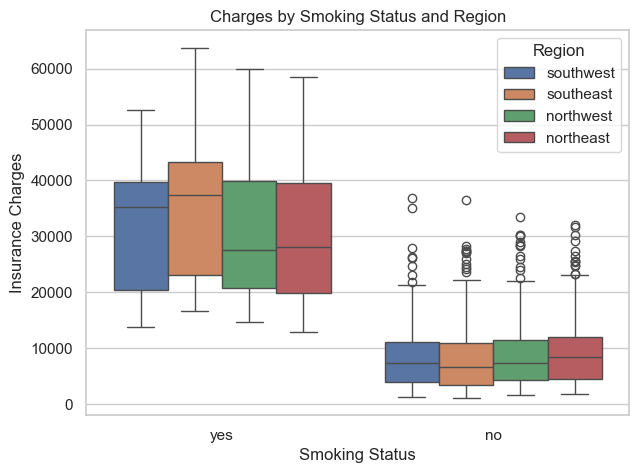

In [404]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x="bmi", y="charges", hue="smoker", alpha=0.8)
plt.title("BMI vs Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x="smoker", y="charges", hue="region")
plt.title("Charges by Smoking Status and Region")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")
plt.legend(title="Region")
plt.show()

#### Multivariate Observations :

- `BMI vs Charges by Smoking Status`
Insurance charges generally increase with BMI, but the relationship is much stronger for smokers. Smokers have substantially higher charges than non-smokers across similar BMI ranges.
- `Charges by Smoking Status and Region`
Smokers have considerably higher insurance charges than non-smokers across all regions. Regional differences are relatively small compared with the effect of smoking status, although some variation and outliers are present.
- `Overall Observation`
Smoking status appears to be the most influential factor, with BMI and region contributing additional variation in insurance charges. The combination of BMI and smoking status shows a clearer relationship with insurance charges than region and smoking status.

### Correlation Analysis :

In [405]:
correlation = data.select_dtypes(include='number').corr()

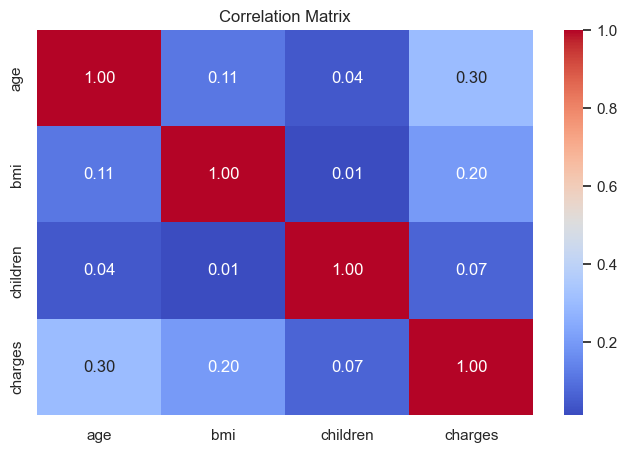

,age,bmi,children,charges
age,1.000,0.109,0.042,0.298
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.067
charges,0.298,0.198,0.067,1.000


In [406]:
plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

correlation

#### Observations :

- `Age and Charges`
Age and charges have the strongest positive correlation (0.30), indicating that charges tend to increase with age.
- `BMI and Charges` Show a weak positive correlation (0.20).
- `Children and Charges` Have a very weak correlation (0.07), suggesting little linear relationship.
- `Overall` Age has the strongest correlation with insurance charges among the numerical variables, but the correlations are not very strong

### Outlier Analysis

A box plot alone does not establish that an observation is erroneous. Outliers are first quantified using the IQR rule and then interpreted in context.

For this dataset:
- `bmi` has a small number of IQR-flagged observations.
- `charges` has a larger upper-tail population because the target is strongly right-skewed.
- High `charges` are plausible outcomes rather than obvious data-entry errors.

In [407]:
columns = ["age", "bmi", "children", "charges"]

result = []

for col in columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_limit) | (data[col] > upper_limit)]

    result.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outlier Count": len(outliers)
    })

outlier_report = pd.DataFrame(result)

outlier_report

,Feature,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count
0,age,27.000,51.000,24.000,-9.000,87.000,0
1,bmi,26.290,34.700,8.410,13.675,47.315,9
2,children,0.000,2.000,2.000,-3.000,5.000,0
3,charges,"4,746.344","16,657.717","11,911.373","-13,120.716","34,524.778",139


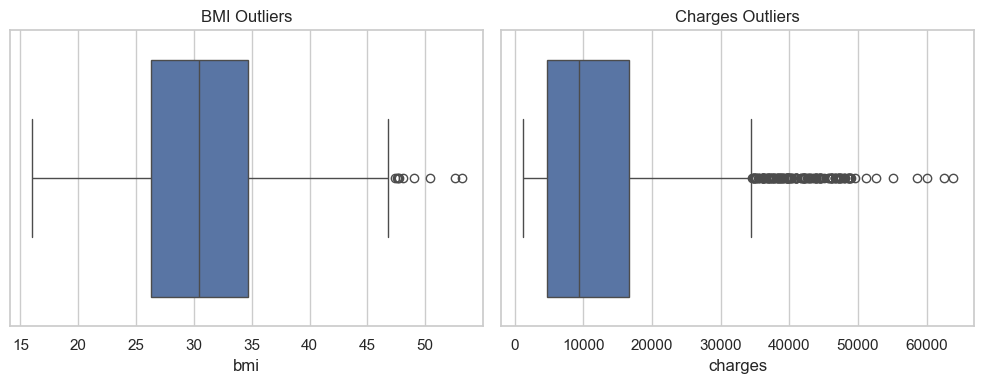

In [408]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=data["bmi"])
plt.title("BMI Outliers")

plt.subplot(1, 2, 2)
sns.boxplot(x=data["charges"])
plt.title("Charges Outliers")

plt.tight_layout()
plt.show()

### Observations

The IQR rule flags 9 BMI observations and 139 charges observations in the dataset as outliers. The outliers are retained in the dataset, as they may represent valid real-world observations.

- The insurance charges contain several high-value observations, which is consistent with the right-skewed nature of the target variable.
- No outlier removal or transformation is performed in this analysis, as these values may contain important information for predicting insurance charges.

## Feature Engineering and Data Preprocessing

In [409]:
# Target Variable

x=data.drop('charges',axis=1)
y=data['charges']

# Separate Numerical and Categorical Columns

numeric_features = ['age','bmi','children']
categorical_features = ['sex','smoker','region']

# Train and Testing Data Split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=TEST_SIZE,random_state=RANDOM_STATE)

print('Training Rows:', len(x_train))
print('Testing Rows:', len(x_test))

Training Rows: 1069
Testing Rows: 268


### Categorical Encoding

In [410]:
# Convert Categorical Variables into Numbers

x_train = pd.get_dummies(x_train, columns=categorical_features, drop_first=True)
x_test = pd.get_dummies(x_test, columns=categorical_features, drop_first=True)

# Renaming the both datasets features to same name  
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)



In [411]:
display(x_train.head())
print(x_train.shape)
print(x_test.shape)

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1113,23,24.510,0,True,False,False,False,False
967,21,25.745,2,True,False,False,False,False
598,52,37.525,2,False,False,True,False,False
170,63,41.470,0,True,False,False,True,False
275,47,26.600,2,False,False,False,False,False


(1069, 8)
(268, 8)


### Scaling of Numerical Features

In [412]:
x_train[numeric_features]

,age,bmi,children
1113,23,24.510,0
967,21,25.745,2
598,52,37.525,2
170,63,41.470,0
275,47,26.600,2
...,...,...,...
1095,51,34.960,2
1130,27,45.900,2
1294,20,22.000,1
860,38,28.000,3


In [413]:
scaler = StandardScaler()

x_train[numeric_features]=scaler.fit_transform(x_train[numeric_features])
x_test[numeric_features]=scaler.transform(x_test[numeric_features])

## Model Development

The following regression algorithms were trained and evaluated:

1. Linear Regression — interpretable baseline model
2. Decision Tree — nonlinear single-tree model
3. Random Forest — bagging ensemble
4. Gradient Boosting — sequential boosting ensemble
5. XGBoost — optimized gradient-boosting implementation
6. KNN — distance-based regression model
7. SVR — kernel-based nonlinear model

### Linear Regression

#### Model Building

In [414]:
# Create the model

linear_model = LinearRegression()

# Train the model

linear_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Model Evaluation

In [415]:
# Make Predictions

y_pred_linear=linear_model.predict(x_test)

# Calculate Evaluation Metrics

linear_mae=mean_absolute_error(y_test,y_pred_linear)
linear_mse=mean_squared_error(y_test,y_pred_linear)
linear_rmse=np.sqrt(mean_squared_error(y_test,y_pred_linear))
linear_r2=r2_score(y_test,y_pred_linear)

print('Linear Regression')
print('MAE: ',linear_mae)
print('MSE: ',linear_mse)
print('RMSE: ',linear_rmse)
print('R2 Score: ',linear_r2)



Linear Regression
MAE:  4177.045561036321
MSE:  35478020.67523555
RMSE:  5956.342894363584
R2 Score:  0.8069287081198014


### Decision Tree Regressor

#### Model Building

In [416]:
# Create the model

decision_tree=DecisionTreeRegressor(random_state=RANDOM_STATE)

# Train the model

decision_tree.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

#### Model Evaluation

In [417]:
# Make predictions

y_pred_tree = decision_tree.predict(x_test)

# Calculate Evaluation Metrics

tree_mae=mean_absolute_error(y_test,y_pred_tree)
tree_mse=mean_squared_error(y_test,y_pred_tree)
tree_rmse=np.sqrt(mean_squared_error(y_test,y_pred_tree))
tree_r2=r2_score(y_test,y_pred_tree)

print('Decision Tree')
print('MAE: ',tree_mae)
print('MSE: ',tree_mse)
print('RMSE: ',tree_rmse)
print('R2 Score: ',tree_r2)


Decision Tree
MAE:  2804.8116326828363
MSE:  34953028.963362776
RMSE:  5912.108673169225
R2 Score:  0.8097857115858496


### Random Forest Regressor

#### Model Building

In [418]:
# Create the model

random_forest=RandomForestRegressor(n_estimators=300,random_state=RANDOM_STATE)

# Train the model

random_forest.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### Model Evaluation

In [419]:
# Make predictions

y_pred_forest = random_forest.predict(x_test)

# Calculate Evaluation Metrics

forest_mae=mean_absolute_error(y_test,y_pred_forest)
forest_mse=mean_squared_error(y_test,y_pred_forest)
forest_rmse=np.sqrt(mean_squared_error(y_test,y_pred_forest))
forest_r2=r2_score(y_test,y_pred_forest)

print('Random Forest')
print('MAE: ',forest_mae)
print('MSE: ',forest_mse)
print('RMSE: ',forest_rmse)
print('R2 Score: ',forest_r2)


Random Forest
MAE:  2644.9283867847
MSE:  22098633.921038948
RMSE:  4700.918412506108
R2 Score:  0.8797392943935918


### Gradient Boosting Regressor

#### Model Building

In [420]:
# Create the model

gradient_boosting=GradientBoostingRegressor(n_estimators=100,
                                            learning_rate=0.1,
                                            random_state=RANDOM_STATE)

# Train the model

gradient_boosting.fit(x_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

#### Model Evaluation

In [421]:
# Make predictions

y_pred_gradient = gradient_boosting.predict(x_test)

# Calculate Evaluation Metrics

gradient_mae=mean_absolute_error(y_test,y_pred_gradient)
gradient_mse=mean_squared_error(y_test,y_pred_gradient)
gradient_rmse=np.sqrt(mean_squared_error(y_test,y_pred_gradient))
gradient_r2=r2_score(y_test,y_pred_gradient)

print('Gradient Boosting')
print('MAE: ',gradient_mae)
print('MSE: ',gradient_mse)
print('RMSE: ',gradient_rmse)
print('R2 Score: ',gradient_r2)


Gradient Boosting
MAE:  2517.4678305027105
MSE:  18218239.91837331
RMSE:  4268.283017604774
R2 Score:  0.9008563879867466


### XGBoost Regressor

#### Model Building

In [422]:
# Create the model

xgb_model=XGBRegressor(n_estimators=100,
                       learning_rate=0.1,
                       max_depth=3,
                       random_state=RANDOM_STATE)

# Train the model

xgb_model.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

#### Model Evaluation

In [423]:
# Make predictions

y_pred_xgb = xgb_model.predict(x_test)

# Calculate Evaluation Metrics

xgb_mae=mean_absolute_error(y_test,y_pred_xgb)
xgb_mse=mean_squared_error(y_test,y_pred_xgb)
xgb_rmse=np.sqrt(mean_squared_error(y_test,y_pred_xgb))
xgb_r2=r2_score(y_test,y_pred_xgb)

print('XGBoost')
print('MAE: ',xgb_mae)
print('MSE: ',xgb_mse)
print('RMSE: ',xgb_rmse)
print('R2 Score: ',xgb_r2)


XGBoost
MAE:  2484.490609870336
MSE:  18009839.90912886
RMSE:  4243.800173091196
R2 Score:  0.9019905002694184


### KNN Regressor

#### Model Building

In [424]:
# Create the model

knn_model=KNeighborsRegressor(n_neighbors=5)

# Train the model

knn_model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Model Evaluation

In [425]:
# Make predictions

y_pred_knn = knn_model.predict(x_test)

# Calculate Evaluation Metrics

knn_mae=mean_absolute_error(y_test,y_pred_knn)
knn_mse=mean_squared_error(y_test,y_pred_knn)
knn_rmse=np.sqrt(mean_squared_error(y_test,y_pred_knn))
knn_r2=r2_score(y_test,y_pred_knn)

print('KNN')
print('MAE: ',knn_mae)
print('MSE: ',knn_mse)
print('RMSE: ',knn_rmse)
print('R2 Score: ',knn_r2)


KNN
MAE:  4496.305288503731
MSE:  65007082.01080882
RMSE:  8062.696944001357
R2 Score:  0.6462316367623702


### Support Vector Regressor (SVR)

#### Model Building

In [426]:
# Create the model

svr_model = SVR(kernel='rbf')

# Train the model

svr_model.fit(x_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


#### Model Evaluation

In [427]:
# Make predictions

y_pred_svr = svr_model.predict(x_test)

# Calculate Evaluation Metrics

svr_mae=mean_absolute_error(y_test,y_pred_svr)
svr_mse=mean_squared_error(y_test,y_pred_svr)
svr_rmse=np.sqrt(mean_squared_error(y_test,y_pred_svr))
svr_r2=r2_score(y_test,y_pred_svr)

print('SVR')
print('MAE: ',svr_mae)
print('MSE: ',svr_mse)
print('RMSE: ',svr_rmse)
print('R2 Score: ',svr_r2)


SVR
MAE:  9261.820813731363
MSE:  208257131.33082858
RMSE:  14431.11677351509
R2 Score:  -0.13333474145511315


### Model Comparison

In [428]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "KNN",
        "SVR"
    ],
    
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae,
        gradient_mae,
        xgb_mae,
        knn_mae,
        svr_mae
    ],

    "MSE": [
        linear_mse,
        tree_mse,
        forest_mse,
        gradient_mse,
        xgb_mse,
        knn_mse,
        svr_mse
    ],
    
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse,
        gradient_rmse,
        xgb_rmse,
        knn_rmse,
        svr_rmse
    ],
    
    "R2": [
        linear_r2,
        tree_r2,
        forest_r2,
        gradient_r2,
        xgb_r2,
        knn_r2,
        svr_r2
    ]
})

model_results = model_results.sort_values("RMSE").reset_index(drop=True)

display(model_results.round(3))

,Model,MAE,MSE,RMSE,R2
0,XGBoost,"2,484.491","18,009,839.909","4,243.800",0.902
1,Gradient Boosting,"2,517.468","18,218,239.918","4,268.283",0.901
2,Random Forest,"2,644.928","22,098,633.921","4,700.918",0.880
3,Decision Tree,"2,804.812","34,953,028.963","5,912.109",0.810
4,Linear Regression,"4,177.046","35,478,020.675","5,956.343",0.807
5,KNN,"4,496.305","65,007,082.011","8,062.697",0.646
6,SVR,"9,261.821","208,257,131.331","14,431.117",-0.133


## Cross-Validation

In [429]:
# Fold Cross Validation for XGBoost :

from sklearn.model_selection import cross_val_score, KFold

# create 5 folds
cv = KFold(n_splits=5, shuffle = True, random_state=RANDOM_STATE)

# Perform Cross Validation
cv_scores=cross_val_score(xgb_model,x_train,y_train,cv=cv,scoring="r2")

print("R2 scores for each fold:", cv_scores)
print("Mean R2:",cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

R2 scores for each fold: [0.82227983 0.83413048 0.88786601 0.80854565 0.84371343]
Mean R2: 0.8393070832468252
Standard Deviation: 0.026982865329336064


In [430]:
rmse_scores = cross_val_score(xgb_model, x_train, y_train, cv=cv, scoring = "neg_root_mean_squared_error")

# convert negative values to positive

rmse_scores=-rmse_scores

print("RMSE scores for each fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Standard Deviation:", rmse_scores.std())


RMSE scores for each fold: [4735.30919339 4580.81786445 4307.90983256 4890.72777494 4684.37103628]
Mean RMSE: 4639.827140321649
Standard Deviation: 193.75412429532406


#### Check XGBoost Overfitting

In [431]:
# Predictions on training data 
xgb_train_pred = xgb_model.predict(x_train)

# Predictions on testing data
xgb_test_pred = xgb_model.predict(x_test)

# Training R2
train_r2 = r2_score(y_train,xgb_train_pred)

# Testing R2
test_r2 = r2_score(y_test,xgb_test_pred)

# RMSE_train
train_rmse=np.sqrt(mean_squared_error(y_train, xgb_train_pred))

# RMSE test
test_rmse=np.sqrt(mean_squared_error(y_test, xgb_test_pred))

print("Training R2:", train_r2)
print("Testing R2:", test_r2)
print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)


Training R2: 0.883542663931701
Testing R2: 0.9019905002694184
Training RMSE: 3993.0837395219523
Testing RMSE: 4243.800173091196


#### Observations :

- XGBoost achieved a mean cross-validation R² of 0.84 with a standard deviation of 0.026 across five folds.
- The model showed relatively consistent performance across the folds.
- The training and testing performance were also similar, with training R² score of 0.88 and testing R² score of 0.90, while the training and testing RMSE values were 3993.08 and 4,243.80 respectively.

Therefore, there is no clear indication of significant overfitting in the current XGBoost model.

## Hyperparameter Tuning

#### Using Grid Search CV

In [432]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor

# Create XGBoost Model

xgb_model_grid = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE)

# Define the parameters

param_grid={'n_estimators': [100,200,300,400],
           'learning_rate': [0.03,0.05,0.1],
           'max_depth': [2,3,4],
           'subsample': [0.8,1.0],
           'colsample_bytree':[0.8,1.0]}

# Create GridSearchCV

xgb_grid=GridSearchCV(estimator=xgb_model_grid,
                     param_grid=param_grid,
                     scoring='neg_root_mean_squared_error',
                     cv=5,
                     n_jobs=-1)

# Run the Tuning

xgb_grid.fit(x_train,y_train)

# Extract the best Parameters :

print("Best Parameters")
print(xgb_grid.best_params_)

# See Best CV RMSE :

print("Best CV RMSE:", -xgb_grid.best_score_)

Best Parameters
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV RMSE: 4575.687020834316


In [433]:
## Get the Tuned Model :

tuned_xgb_model_grid = xgb_grid.best_estimator_
tuned_pred_grid=tuned_xgb_model_grid.predict(x_test)

# Evaluate the Tuned Model :

tuned_mae_grid = mean_absolute_error(y_test, tuned_pred_grid)
tuned_mse_grid = mean_squared_error(y_test, tuned_pred_grid)
tuned_rmse_grid = np.sqrt(tuned_mse_grid)
tuned_r2_grid = r2_score(y_test, tuned_pred_grid)

print("Tuned XGBoost_Grid")
print("MAE :", tuned_mae_grid)
print("MSE :", tuned_mse_grid)
print("RMSE:", tuned_rmse_grid)
print("R2  :", tuned_r2_grid)

Tuned XGBoost_Grid
MAE : 2490.47959168441
MSE : 17976120.40168646
RMSE: 4239.825515476605
R2  : 0.9021740017370754


#### Using Random Search CV

In [434]:
# Import RandomSearchCV

from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBRegressor

# Create XGBoost Model

xgb_model_random = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE)

# Define the parameters

param_grid={'n_estimators': [100,200,300,400,500],
           'learning_rate': [0.1,0.03,0.05,0.1],
           'max_depth': [2,3,4,5],
           'subsample': [0.7,0.8,0.9,1.0],
           'colsample_bytree':[0.7,0.8,0.9,1.0]}

# Create RandomSearchCV

xgb_random=RandomizedSearchCV(estimator=xgb_model_random,
                     param_distributions=param_grid,
                     n_iter=30,
                     scoring='neg_root_mean_squared_error',
                     cv=5,
                     random_state=RANDOM_STATE,
                     n_jobs=-1)

# Run the Tuning

xgb_random.fit(x_train,y_train)

# Extract the best Parameters :

print("Best Parameters")
print(xgb_random.best_params_)

# See Best CV RMSE :

print("Best CV RMSE:", -xgb_random.best_score_)

Best Parameters
{'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV RMSE: 4583.58231714676


In [435]:
## Get the Tuned Model :

tuned_xgb_model_random = xgb_random.best_estimator_
tuned_pred_random=tuned_xgb_model_random.predict(x_test)

# Evaluate the Tuned Model :

tuned_mae_random = mean_absolute_error(y_test, tuned_pred_random)
tuned_mse_random = mean_squared_error(y_test, tuned_pred_random)
tuned_rmse_random = np.sqrt(tuned_mse_random)
tuned_r2_random = r2_score(y_test, tuned_pred_random)

print("Tuned XGBoost Random")
print("MAE :", tuned_mae_random)
print("MSE :", tuned_mse_random)
print("RMSE:", tuned_rmse_random)
print("R2  :", tuned_r2_random)

Tuned XGBoost Random
MAE : 2444.813384800373
MSE : 17863088.755122155
RMSE: 4226.4747432253935
R2  : 0.9027891196498046


In [436]:
## Original vs Tuned Model Metrics :

comparison = pd.DataFrame({
    'Model': ['Original XGBoost', 'Tuned XGBoost Grid', 'Tuned XGBoost Random'],
    'MAE': [xgb_mae, tuned_mae_grid, tuned_mae_random],
    'RMSE':[xgb_rmse, tuned_rmse_grid, tuned_rmse_random],
    'R2':[xgb_r2, tuned_r2_grid, tuned_r2_random]
})

display(comparison.round(3))

,Model,MAE,RMSE,R2
0,Original XGBoost,"2,484.491","4,243.800",0.902
1,Tuned XGBoost Grid,"2,490.480","4,239.826",0.902
2,Tuned XGBoost Random,"2,444.813","4,226.475",0.903


### Observations :

- Hyperparameter tuning was performed using both GridSearchCV and RandomizedSearchCV, with 5-fold cross validation to identify suitable parameter combinations.
- The original XGBoost achieved an RMSE of 4,243.80 and R² of 0.902, compared with GridSearch XGBoost an RMSE of 4,239.82 and R² of 0.902 and RandomSearch XGBoost an RMSE of 4,226.47 and R² of 0.903.
- The RandomSearch XGBoost achieved the lowest RMSE 4,226.47 and the highest R² 0.903. Therefore, the RandomSearch XGBoost model is retained as the final model.
- The GridSearch XGBoost model showing performance very close to the Original XGBoost model, with an RMSE of 4,239.826, MAE of 2,490.480, and R² of 0.902, 
- Overall, the three XGBoost models show very similar performance, with only small differences in their evaluation metrics. Based on the lowest RMSE and highest R², the Random Search tuned XGBoost is retained as the final model for predicting insurance charges.

### Model Comparison :

In [437]:
# Original Metrics Backup

final_comparison = model_results.copy()

# Add GridSearch XGBoost

grid_row = pd.DataFrame([{
    "Model": "GridSearch XGBoost",
    "MAE": tuned_mae_grid,
    "MSE": tuned_mse_grid,
    "RMSE": tuned_rmse_grid,
    "R2": tuned_r2_grid
}])

# Add RandomSearch XGBoost

random_row = pd.DataFrame([{
    "Model": "RandomSearch XGBoost",
    "MAE": tuned_mae_random,
    "MSE": tuned_mse_random,
    "RMSE": tuned_rmse_random,
    "R2": tuned_r2_random
}])

# Combine all models

final_comparison = pd.concat(
    [final_comparison, grid_row, random_row],
    ignore_index=True
)

# Sort by RMSE

final_comparison = final_comparison.sort_values("RMSE").reset_index(drop=True)

display(final_comparison.round(3))


,Model,MAE,MSE,RMSE,R2
0,RandomSearch XGBoost,"2,444.813","17,863,088.755","4,226.475",0.903
1,GridSearch XGBoost,"2,490.480","17,976,120.402","4,239.826",0.902
2,XGBoost,"2,484.491","18,009,839.909","4,243.800",0.902
3,Gradient Boosting,"2,517.468","18,218,239.918","4,268.283",0.901
4,Random Forest,"2,644.928","22,098,633.921","4,700.918",0.880
5,Decision Tree,"2,804.812","34,953,028.963","5,912.109",0.810
6,Linear Regression,"4,177.046","35,478,020.675","5,956.343",0.807
7,KNN,"4,496.305","65,007,082.011","8,062.697",0.646
8,SVR,"9,261.821","208,257,131.331","14,431.117",-0.133


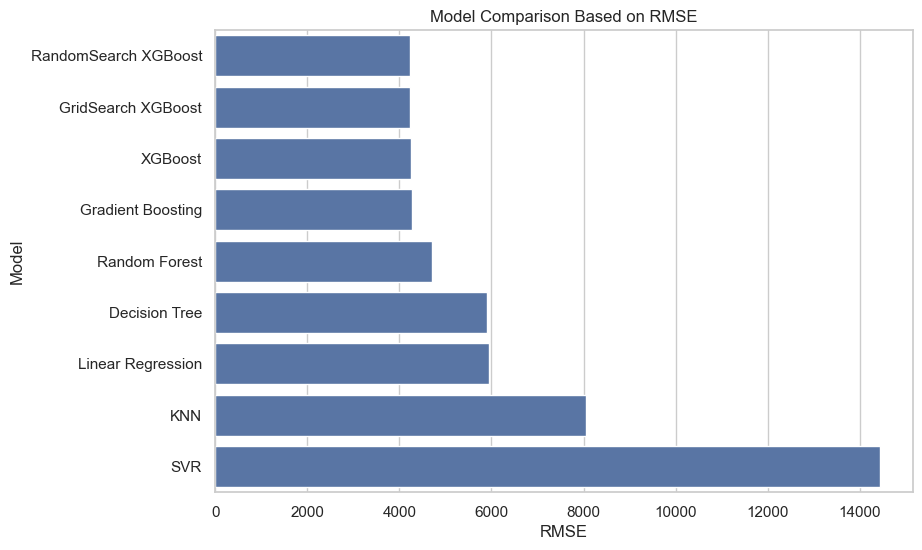

In [438]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=final_comparison,
    x="RMSE",
    y="Model"
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.show()

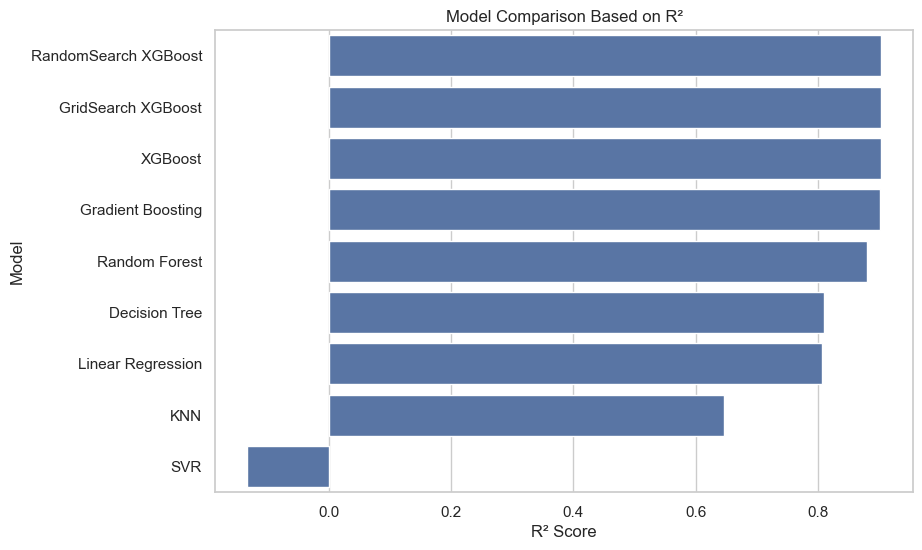

In [439]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=final_comparison,
    x="R2",
    y="Model"
)

plt.title("Model Comparison Based on R²")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

### Observations :

- Among the models evaluated on the held-out test set, the Random Search tuned XGBoost produced the lowest RMSE of approximately 4226.47 and an highest R² of approximately 0.903 The tuned GridSearch XGBoost with Original XGBoost and Gradient Boosting models show similar performance, while Random Forest, Decision Tree, Linear Regression, KNN, and SVR have comparatively higher prediction errors. **Therefore, the RandomSearch XGBoost model is retained as the final model for insurance charge prediction.**

## Final Model Diagnostic - Actual vs Predicted Graph & Residual Analysis

### Actual vs Predicted Graph :

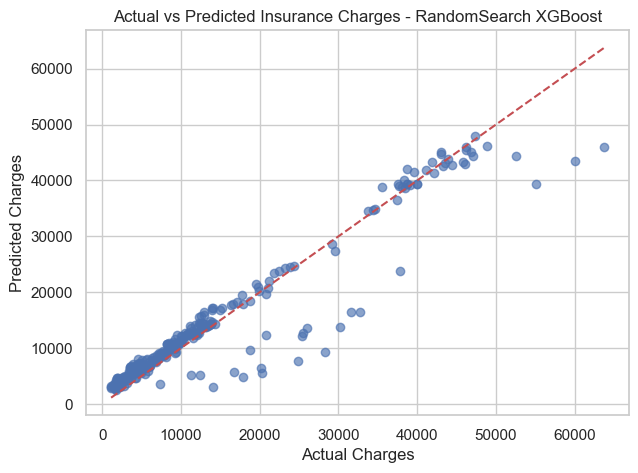

In [440]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,tuned_pred_random,alpha=0.65)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--")

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title("Actual vs Predicted Insurance Charges - RandomSearch XGBoost")

plt.show()

### Residual Analysis :

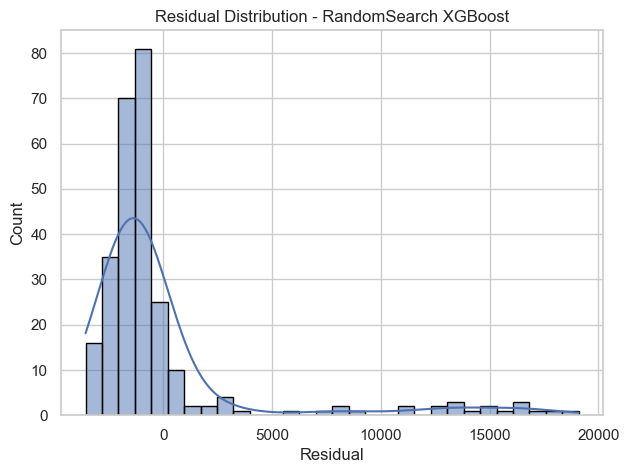

In [441]:
residuals = y_test - tuned_pred_random

plt.figure(figsize=(7,5))

sns.histplot(residuals, bins=30, edgecolor='black', kde=True)

plt.title('Residual Distribution - RandomSearch XGBoost')
plt.xlabel('Residual')
plt.ylabel('Count')

plt.show()



### Observations :

- The residual distribution shows the difference between actual charges vs the predicted charges by model.
- Here the residual distribution is centered relatively close to zero, indicating that the XGBoost model generally makes reasonably accurate predictions. However the distribution is right-skewed with some large positive residuals, showing that the model has larger errors for few high insurance charges.

## Challenges Faced

#### Dataset Loading and File Path

- `Challenge:` The dataset was not initially available in the default notebook location.
- `Solution:` Identified the correct file path and loaded the dataset using pandas.
- `Learning:` Understood how to locate and load external datasets into a Python environment.

#### Duplicate Records

- `Challenge:` A duplicate record was identified in the dataset.
- `Solution:` Used duplicated() to identify duplicates and drop_duplicates() to remove them.
- `Learning:` Duplicate observations can affect analysis and model training, so data quality checks are important.

#### Data Preprocessing

- `Challenge:` The dataset contained categorical variables and required preparation before applying machine learning algorithms.
- `Solution:` Handled categorical variables using One-Hot Encoding and prepared numerical variables for modeling.
- `Learning:` Understood that raw data cannot always be directly given to machine learning models.

#### Different Model Requirements

- `Challenge:` Different algorithms required different preprocessing approaches.For example, KNN and SVR, are sensitive to the scale of numerical features.
- `Solution:` Used StandardScaler for models where feature scaling was required.
- `Learning:` Model selection can affect the preprocessing steps required.

#### XGBoost Installation and Setup

- `Challenge:` XGBoost was not initially installed in the environment, which caused an import error.
- `Solution:` Installed the XGBoost library using pip and then imported XGBRegressor.
- `Learning:` External machine learning libraries may need to be installed and configured before use.

#### Outlier Detection

- `Challenge:` Outliers were identified in variables such as BMI and insurance charges. Some extreme insurance charges appeared to be genuine observations rather than data-entry errors.
- `Solution:` Used boxplots and the IQR method to identify and examine the outliers. The observations were retained rather than automatically removed.
- `Learning:` An outlier is not necessarily an error and should be examined before making changes to the dataset.

#### Model Comparison

- `Challenge:` Different regression algorithms produced different prediction results.
- `Solution:` Compared models using MAE, RMSE, and R².
- `Learning:` Using multiple evaluation metrics provides a better understanding of model performance.

#### Model Tuning

- `Challenge:` The initial XGBoost model performed well, but there was a possibility of improving its performance and reducing overfitting.
- `Solution:` Used GridSearchCV and RandomizedSearchCV to test different XGBoost hyperparameters.
- `Learning:` Hyperparameter tuning does not always improve test performance, so tuned models need to be compared with the original model.

#### Final Model Selection
The Random Search tuned XGBoost model was selected as the final model because it achieved the lowest RMSE and MAE, along with the highest R² among the evaluated XGBoost models.

## Deployment

In [442]:
# Create Pickle Files :

import pickle

# Pickled trained XGBooost Model :

with open('model.pkl','wb') as file:
    pickle.dump(tuned_xgb_model_random, file)

# Pickled Scaler :

with open('scaler.pkl','wb') as file:
    pickle.dump(scaler, file)

# Pickled the feature columns :

with open('columns.pkl','wb') as file:
    pickle.dump(x_train.columns.tolist(), file)

print("All Pickle Files Created Successfully")

All Pickle Files Created Successfully


## Summary

The objective of this project was to analyze the Medical Insurance dataset and develop a Machine Learning model to predict insurance charges based on customer and health-related features.

Exploratory Data Analysis was performed to understand the distribution of variables and their relationships with insurance charges. The analysis indicated that smoking status, age, and BMI have important relationships with insurance charges, while the number of children showed a comparatively weaker relationship.

Several regression algorithms were trained and evaluated, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, KNN, and SVR.

Among the evaluated models, RandomSearch XGBoost performed best overall. The RandomSearch XGBoost model achieved an RMSE of approximately 4,226, an MAE of approximately 2,444, and an R² score of approximately 0.903 on the test dataset.

Cross-validation was also performed to assess the consistency of the XGBoost model across different data splits. The model achieved a mean cross-validation R² of approximately 0.84, indicating reasonably consistent performance across the folds.

Hyperparameter tuning was performed using both GridSearchCV and RandomizedSearchCV. The RandomSearch tuned XGBoost model was selected as the final model based on its overall test-set performance compared with the other evaluated models.

The final trained model and preprocessing components were saved using Pickle and integrated into a Streamlit web application, which was deployed to provide an interactive interface for predicting estimated medical insurance charges.

Overall, the project demonstrates an end-to-end Machine Learning workflow combining data analysis, preprocessing, exploratory analysis, model comparison, cross-validation, hyperparameter tuning, model serialization, and deployment to build a practical regression solution for medical insurance charge prediction.